# Conflict-Induced Food Crisis Prediction
## Task 2: Feature Engineering & Exploratory Data Analysis  v2.0

**Input** : `panel_dataset.csv` (from Task 1) + `data_quality_report.json`  
**Output** : `features_engineered.csv`, train/val/test splits, charts, `split_report.json`

---

### Notebook Structure

| Step | Section | What it does |
|------|---------|-------------|
| 1 | Setup | Install, import, auto-detect environment |
| 2 | Load Panel | Read Task 1 output, validate schema |
| 3 | Lag Features | Conflict & rainfall temporal lags (1–3 months) |
| 4 | Rolling Features | 2-month and 3-month rolling averages |
| 5 | IPC Trend | Slope of IPC phase over prior 3 months |
| 6 | Compound Risk | Conflict × drought interaction features |
| 7 | Feature Catalogue | Document every feature with source & correlation |
| 8 | EDA | 6-panel chart — crisis rate, country breakdown, distributions |
| 9 | RF Pre-screen | 100-tree importance ranking before Task 3 |
| 10 | Walk-Forward Split | Temporal train/val/test — strict no-leakage |
| 11 | Save Artifacts | All CSVs + split_report.json |
| 12 | Drive Backup | Google Drive (Colab) or local summary |

---

### Anti-leakage rules enforced in this notebook
- All lag/rolling features use `.shift(1)` before rolling → **no current-month leakage**
- `crisis_90d` uses only **forward** IPC shifts — confirmed in Task 1
- Temporal split is **strictly ordered** — no row from the future ever enters training
- Test set is **sealed** — not opened until Task 4


---
## Step 1 — Setup & Auto-Detect Environment

In [1]:
# ── Auto-install any missing packages ────────────────────────────────────────
import subprocess, sys, os

def install(pkg):
    try:
        __import__(pkg.split('[')[0].replace('-', '_'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['scikit-learn', 'matplotlib', 'seaborn', 'scipy']:
    install(pkg)

import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Auto-detect: Colab vs Local ───────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    DATA_DIR = Path('/content/crisis_outputs')
else:
    LOCAL_DATA = Path(r'D:\Project\10academy\Conflict-Induced Food Crisis Prediction\data')
    DATA_DIR   = LOCAL_DATA if LOCAL_DATA.exists() else Path.cwd() / 'data'

OUTPUT_DIR = DATA_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f'Environment : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Data dir    : {DATA_DIR}')
print(f'Existing CSVs:')
for f in sorted(DATA_DIR.glob('*.csv')):
    print(f'  {f.name:<45} {f.stat().st_size/1024:>8.1f} KB')
print('\n Setup complete.')


Installing scikit-learn...
Environment : Google Colab
Data dir    : /content/crisis_outputs
Existing CSVs:

 Setup complete.


In [3]:
# ── Mount Drive & restore backup ────────────────────────────────────────────
from google.colab import drive
import shutil

drive.mount('/content/drive')

BACKUP_SRC = Path('/content/drive/MyDrive/crisis_outputs_backup')

if BACKUP_SRC.exists():
    if not any(DATA_DIR.iterdir()):
        print(f'Restoring from {BACKUP_SRC} ...')
        for item in BACKUP_SRC.iterdir():
            dst = DATA_DIR / item.name
            shutil.copytree(str(item), str(dst), dirs_exist_ok=True) if item.is_dir()                 else shutil.copy2(str(item), str(dst))
        print(' Restore complete.')
    else:
        print(' Files already present — skipping restore.')
else:
    print('  No backup found — will run all steps from scratch.')

# List what we have
existing = sorted(DATA_DIR.glob('*.csv'))
print(f'\nExisting CSVs ({len(existing)}):')
for f in existing:
    print(f'  {f.name:<45} {f.stat().st_size/1024:>8.1f} KB')


Mounted at /content/drive
Restoring from /content/drive/MyDrive/crisis_outputs_backup ...
 Restore complete.

Existing CSVs (26):
  X_test.csv                                      1289.3 KB
  X_train.csv                                     2207.3 KB
  X_val.csv                                        621.3 KB
  acled_africa_raw.csv                           10334.1 KB
  acled_monthly.csv                               1766.5 KB
  chirps_monthly.csv                              2016.7 KB
  chirps_processed.csv                            2016.7 KB
  feature_importance.csv                             2.0 KB
  features_engineered.csv                         5791.2 KB
  features_manifest.csv                              1.4 KB
  fews_net_ipc_admin1 (1).csv                   311841.7 KB
  fews_net_ipc_admin1.csv                       311504.7 KB
  fewsnet_ipc.csv                                 1027.6 KB
  model_dataset.csv                               2056.2 KB
  panel_dataset.csv           

---
## Step 2 — Load Panel & Validate Schema

In [4]:
# ── Load Task 1 outputs ───────────────────────────────────────────────────────
PANEL_PATH  = DATA_DIR / 'panel_dataset.csv'
REPORT_PATH = DATA_DIR / 'data_quality_report.json'

if not PANEL_PATH.exists():
    raise FileNotFoundError(
        f"panel_dataset.csv not found in {DATA_DIR}\n"
        "Run Task 1 (Crisis_task1_data_collection.ipynb) first."
    )

panel = pd.read_csv(PANEL_PATH)
with open(REPORT_PATH) as f:
    quality = json.load(f)

# ── Schema validation ─────────────────────────────────────────────────────────
REQUIRED_COLS = [
    'country', 'admin1', 'year_month', 'ipc_phase',
    'crisis_90d', 'ipc_lag1', 'ipc_lag2',
    'fatalities_30d', 'events_30d', 'battle_events',
    'civilian_violence', 'conflict_trend',
    'rainfall_mm', 'rainfall_anomaly', 'is_drought', 'is_flood',
    'is_lean_season', 'is_harvest_season', 'year'
]
missing_cols = [c for c in REQUIRED_COLS if c not in panel.columns]
assert not missing_cols, f'Missing columns from Task 1: {missing_cols}'

# ── Sort and reset ────────────────────────────────────────────────────────────
panel = panel.sort_values(['country', 'admin1', 'year_month']).reset_index(drop=True)

# ── Summary ───────────────────────────────────────────────────────────────────
print('=== PANEL LOADED ===')
print(f'  Rows           : {len(panel):,}')
print(f'  Columns        : {panel.shape[1]}')
print(f'  Countries      : {panel["country"].nunique()}')
print(f'  Regions        : {panel["admin1"].nunique()}')
print(f'  Date range     : {panel["year_month"].min()} → {panel["year_month"].max()}')
print(f'  Crisis rate    : {panel["crisis_90d"].mean():.1%}')
print(f'  Class imbalance: {(1-panel["crisis_90d"].mean())/panel["crisis_90d"].mean():.1f}:1')
print(f'  scale_pos_weight (Task 1): {quality.get("scale_pos_weight", "n/a")}')
print(f'\nNulls per column:')
nulls = panel.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.sum() > 0 else '  None ')
print(f'\n Schema validated — all {len(REQUIRED_COLS)} required columns present.')


=== PANEL LOADED ===
  Rows           : 26,954
  Columns        : 20
  Countries      : 13
  Regions        : 341
  Date range     : 2018-02 → 2026-01
  Crisis rate    : 39.2%
  Class imbalance: 1.5:1
  scale_pos_weight (Task 1): 1.55

Nulls per column:
ipc_lag1       343
ipc_lag2       686
rainfall_mm     88

 Schema validated — all 19 required columns present.


---
## Step 3 — Temporal Lag Features

**Why lags matter**: Conflict in month T doesn't immediately cause food insecurity.  
The causal chain takes 2–3 months: conflict → market disruption → harvest failure → IPC escalation.

| Feature | Logic | Leakage? |
|---|---|---|
| `fatalities_lag1` | Fatalities from 1 month ago |  No — uses `.shift(1)` |
| `fatalities_lag2` | Fatalities from 2 months ago |  No |
| `fatalities_lag3` | Fatalities from 3 months ago |  No |
| `events_lag1/2` | Event count lags |  No |
| `rainfall_lag1/2` | Rainfall anomaly lags |  No |


In [5]:
# ── Lag feature factory ───────────────────────────────────────────────────────
grp = panel.groupby(['country', 'admin1'])

# Conflict lags (pure historical values)
for lag in [1, 2, 3]:
    panel[f'fatalities_lag{lag}'] = grp['fatalities_30d'].shift(lag)
    panel[f'events_lag{lag}']     = grp['events_30d'].shift(lag)

# Rainfall anomaly lags
for lag in [1, 2]:
    panel[f'rainfall_lag{lag}'] = grp['rainfall_anomaly'].shift(lag)

new_lag_cols = [c for c in panel.columns if 'lag' in c and c not in ['ipc_lag1','ipc_lag2']]
print(f' Lag features created ({len(new_lag_cols)}): {new_lag_cols}')
print(f'Panel shape: {panel.shape}')


 Lag features created (8): ['fatalities_lag1', 'events_lag1', 'fatalities_lag2', 'events_lag2', 'fatalities_lag3', 'events_lag3', 'rainfall_lag1', 'rainfall_lag2']
Panel shape: (26954, 28)


---
## Step 4 — Rolling Window Features

**Why rolling averages**: A single violent month could be random.  
Three consecutive months of rising fatalities is a genuine escalation signal.  
All rolling features use `.shift(1)` before rolling — no current-month leakage.


In [6]:
# ── Rolling features (shift-before-roll = no leakage) ────────────────────────
grp = panel.groupby(['country', 'admin1'])

panel['fatalities_roll2'] = grp['fatalities_30d'].transform(
    lambda x: x.shift(1).rolling(2, min_periods=1).mean())
panel['fatalities_roll3'] = grp['fatalities_30d'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
panel['events_roll3']     = grp['events_30d'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
panel['rainfall_roll3']   = grp['rainfall_anomaly'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())

# Conflict escalation signals
panel['fatalities_delta'] = grp['fatalities_30d'].diff(1)               # month-over-month change
panel['fatalities_accel'] = panel.groupby(['country','admin1'])['fatalities_delta'].diff(1)  # accel

roll_cols = ['fatalities_roll2','fatalities_roll3','events_roll3',
             'rainfall_roll3','fatalities_delta','fatalities_accel']
print(f' Rolling features created ({len(roll_cols)}): {roll_cols}')

# Verify no leakage: rolling(t) must use only data from t-1 and earlier
sample = panel[panel['country'] == panel['country'].iloc[0]].head(5)
print(f'\nLeakage check — first 5 rows for {sample["country"].iloc[0]}/{sample["admin1"].iloc[0]}:')
print(sample[['year_month','fatalities_30d','fatalities_roll2','fatalities_roll3']].to_string(index=False))
print('\n Roll-2 at row 2 = mean of row 0 only (shift=1 confirmed no leakage)')


 Rolling features created (6): ['fatalities_roll2', 'fatalities_roll3', 'events_roll3', 'rainfall_roll3', 'fatalities_delta', 'fatalities_accel']

Leakage check — first 5 rows for Burkina Faso/Boucle Du Mouhoun:
year_month  fatalities_30d  fatalities_roll2  fatalities_roll3
   2021-06          0.0000               NaN               NaN
   2021-07          0.0000            0.0000            0.0000
   2021-08         15.0000            0.0000            0.0000
   2021-09          3.0000            7.5000            5.0000
   2021-10         21.0000            9.0000            6.0000

 Roll-2 at row 2 = mean of row 0 only (shift=1 confirmed no leakage)


---
## Step 5 — IPC Trend Feature

**IPC trend** = the slope (gradient) of the IPC phase over the prior 3 months.  
- Positive (↑): worsening food security — strong leading indicator  
- Zero: stable  
- Negative (↓): improving

This is computed only from **past data** (`.shift(1)` before the rolling window).


In [7]:
# ── IPC trend: linear slope over prior 3 months ───────────────────────────────
grp = panel.groupby(['country', 'admin1'])

panel['ipc_trend'] = grp['ipc_phase'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).apply(
        lambda w: float(np.polyfit(range(len(w)), w, 1)[0]) if len(w) >= 2 else 0.0,
        raw=True
    )
)

print(' ipc_trend created.')
print(f'  Mean ipc_trend (crisis=1) : {panel.loc[panel["crisis_90d"]==1,"ipc_trend"].mean():.4f}')
print(f'  Mean ipc_trend (crisis=0) : {panel.loc[panel["crisis_90d"]==0,"ipc_trend"].mean():.4f}')
print(f'  Correlation with crisis_90d: {panel["ipc_trend"].corr(panel["crisis_90d"]):.4f}')


 ipc_trend created.
  Mean ipc_trend (crisis=1) : 0.0377
  Mean ipc_trend (crisis=0) : -0.0120
  Correlation with crisis_90d: 0.1442


---
## Step 6 — Compound Risk & Interaction Features

**Why compound features**: High conflict AND drought simultaneously is far worse than either alone.  
Neither `fatalities_30d` nor `is_drought` alone captures their synergy — an explicit  
interaction term forces the model to consider the combined effect.

| Feature | Formula | Interpretation |
|---|---|---|
| `high_conflict` | fatalities > median | Binary: above-average violence |
| `high_conflict_drought` | high_conflict AND is_drought | Compound shock flag |
| `compound_risk_score` | 0.6×conflict_norm + 0.4×drought_severity | Weighted severity index 0–1 |
| `sustained_conflict` | lag1 > 0 AND lag2 > 0 | At least 2 consecutive months of violence |
| `battle_share` | battle_events / events_30d | % of events that are direct combat |
| `lean_drought` | is_lean_season AND is_drought | Drought in hunger gap month |


In [8]:
# ── Compound risk features ────────────────────────────────────────────────────
fat_median = panel['fatalities_30d'].median()
fat_95     = panel['fatalities_30d'].quantile(0.95) + 1e-9
rain_min   = panel['rainfall_anomaly'].min()
rain_range = panel['rainfall_anomaly'].max() - rain_min + 1e-9

# Binary flags
panel['high_conflict'] = (panel['fatalities_30d'] > fat_median).astype(int)
panel['high_conflict_drought'] = (
    (panel['high_conflict'] == 1) & (panel['is_drought'] == 1)
).astype(int)

# Normalised severity scores (0–1)
panel['conflict_intensity_norm'] = (panel['fatalities_30d'] / fat_95).clip(0, 1)
panel['drought_severity_norm']   = (-(panel['rainfall_anomaly'] - rain_min) / rain_range).clip(0, 1)

# Weighted compound risk score
panel['compound_risk_score'] = (
    panel['conflict_intensity_norm'] * 0.6 +
    panel['drought_severity_norm']   * 0.4
).round(4)

# Battle share (combat intensity)
panel['battle_share'] = np.where(
    panel['events_30d'] > 0,
    panel['battle_events'] / panel['events_30d'],
    0.0
)

# Sustained conflict (2+ consecutive months of fatalities)
panel['sustained_conflict'] = (
    (panel['fatalities_lag1'].fillna(0) > 0) &
    (panel['fatalities_lag2'].fillna(0) > 0)
).astype(int)

# Lean season × drought compound
panel['lean_drought'] = (
    (panel['is_lean_season'] == 1) & (panel['is_drought'] == 1)
).astype(int)

# Calendar month (non-linear seasonal pattern)
panel['month'] = panel['year_month'].str[5:7].astype(int)

compound_cols = ['high_conflict','high_conflict_drought','compound_risk_score',
                 'sustained_conflict','battle_share','lean_drought']
print(' Compound & interaction features created:')
for col in compound_cols:
    rate_when_crisis = panel.loc[panel['crisis_90d']==1, col].mean()
    rate_when_safe   = panel.loc[panel['crisis_90d']==0, col].mean()
    print(f'  {col:<28}  crisis avg={rate_when_crisis:.3f}  safe avg={rate_when_safe:.3f}  '
          f'diff={rate_when_crisis-rate_when_safe:+.3f}')
print(f'\nPanel shape: {panel.shape}')


 Compound & interaction features created:
  high_conflict                 crisis avg=0.381  safe avg=0.292  diff=+0.089
  high_conflict_drought         crisis avg=0.122  safe avg=0.082  diff=+0.040
  compound_risk_score           crisis avg=0.100  safe avg=0.037  diff=+0.063
  sustained_conflict            crisis avg=0.320  safe avg=0.197  diff=+0.123
  battle_share                  crisis avg=0.178  safe avg=0.092  diff=+0.086
  lean_drought                  crisis avg=0.078  safe avg=0.066  diff=+0.011

Panel shape: (26954, 44)


---
## Step 7 — Feature Catalogue & Correlation Ranking

Every feature is documented with its **data source**, **type**, and **correlation with `crisis_90d`**.  
This auditable record is required for humanitarian AI transparency and reproducibility.


In [10]:
# ── Master feature list ───────────────────────────────────────────────────────
FEATURE_COLS = [
    # ── IPC History (strongest predictors) ──────────────────────────────────
    'ipc_lag1',          # IPC phase 1 month ago              (FEWS NET lag)
    'ipc_lag2',          # IPC phase 2 months ago             (FEWS NET lag)
    'ipc_trend',         # Slope of IPC over prior 3 months   (FEWS NET derived)

    # ── Conflict — current month ─────────────────────────────────────────────
    'fatalities_30d',    # Total fatalities this month         (ACLED)
    'events_30d',        # Total events this month             (ACLED)
    'battle_events',     # Battle/explosion events             (ACLED)
    'civilian_violence', # Violence against civilians          (ACLED)
    'conflict_trend',    # +1 escalating / 0 stable / -1 falling (ACLED derived)
    'battle_share',      # % events that are battles           (ACLED derived)

    # ── Conflict — lagged ────────────────────────────────────────────────────
    'fatalities_lag1',   # Fatalities 1 month ago              (ACLED lag)
    'fatalities_lag2',   # Fatalities 2 months ago             (ACLED lag)
    'fatalities_lag3',   # Fatalities 3 months ago             (ACLED lag)
    'events_lag1',       # Events 1 month ago                  (ACLED lag)
    'events_lag2',       # Events 2 months ago                 (ACLED lag)

    # ── Conflict — rolling windows ───────────────────────────────────────────
    'fatalities_roll2',  # 2-month rolling mean (no leakage)  (ACLED rolling)
    'fatalities_roll3',  # 3-month rolling mean (no leakage)  (ACLED rolling)
    'events_roll3',      # 3-month event rolling mean         (ACLED rolling)
    'fatalities_delta',  # Month-over-month change            (ACLED derived)
    'fatalities_accel',  # Acceleration of fatalities         (ACLED derived)

    # ── Compound Conflict × Climate ──────────────────────────────────────────
    'high_conflict',           # Binary: above median fatalities
    'high_conflict_drought',   # Compound shock flag
    'compound_risk_score',     # Weighted severity 0–1
    'sustained_conflict',      # 2+ consecutive months of violence
    'lean_drought',            # Drought during lean season

    # ── Rainfall / Climate ───────────────────────────────────────────────────
    'rainfall_anomaly',  # Z-score deviation from seasonal mean (CHIRPS)
    'is_drought',        # anomaly < -0.5                      (CHIRPS derived)
    'rainfall_lag1',     # Rainfall anomaly 1 month ago        (CHIRPS lag)
    'rainfall_lag2',     # Rainfall anomaly 2 months ago       (CHIRPS lag)
    'rainfall_roll3',    # 3-month rolling anomaly             (CHIRPS rolling)

    # ── Seasonal / Calendar ──────────────────────────────────────────────────
    'is_lean_season',    # Jun–Sep: pre-harvest hunger gap     (FAO calendar)
    'is_harvest_season', # Oct–Dec: post-harvest relief        (FAO calendar)
    'month',             # Calendar month (1–12)               (derived)
]

TARGET_COL = 'crisis_90d'

# Verify all features exist
missing = [f for f in FEATURE_COLS if f not in panel.columns]
assert not missing, f'Missing features: {missing}'

# ── Compute correlations ──────────────────────────────────────────────────────
corr_series = panel[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
manifest = pd.DataFrame({
    'feature'    : FEATURE_COLS,
    'category'   : [
        'IPC History','IPC History','IPC History',
        'Conflict Current','Conflict Current','Conflict Current','Conflict Current','Conflict Current','Conflict Current',
        'Conflict Lagged','Conflict Lagged','Conflict Lagged','Conflict Lagged','Conflict Lagged',
        'Conflict Rolling','Conflict Rolling','Conflict Rolling','Conflict Rolling','Conflict Rolling',
        'Compound Risk','Compound Risk','Compound Risk','Compound Risk','Compound Risk',
        'Rainfall','Rainfall','Rainfall','Rainfall','Rainfall',
        'Seasonal','Seasonal','Seasonal',
    ],
    'corr_target': corr_series.values.round(4),
    'abs_corr'   : corr_series.abs().values.round(4),
}).sort_values('abs_corr', ascending=False).reset_index(drop=True)

manifest.to_csv(OUTPUT_DIR / 'features_manifest.csv', index=False)

print(f' Feature catalogue saved ({len(FEATURE_COLS)} features)')
print(f'\nTop 15 features by |correlation| with crisis_90d:')
print(manifest.head(15)[['feature','category','corr_target']].to_string(index=False))
print(f'\nFeatures by category:')
print(manifest.groupby('category').size().to_string())


 Feature catalogue saved (32 features)

Top 15 features by |correlation| with crisis_90d:
            feature         category  corr_target
           ipc_lag1      IPC History       0.8440
           ipc_lag2      IPC History       0.8213
compound_risk_score    Compound Risk       0.2042
   fatalities_roll3 Conflict Rolling       0.1741
       battle_share Conflict Current       0.1663
   fatalities_roll2 Conflict Rolling       0.1637
       events_roll3 Conflict Rolling       0.1602
        events_lag2  Conflict Lagged       0.1537
        events_lag1  Conflict Lagged       0.1515
    fatalities_lag3  Conflict Lagged       0.1508
    fatalities_lag2  Conflict Lagged       0.1505
         events_30d Conflict Current       0.1492
          ipc_trend      IPC History       0.1442
  civilian_violence Conflict Current       0.1442
    fatalities_lag1  Conflict Lagged       0.1439

Features by category:
category
Compound Risk       5
Conflict Current    6
Conflict Lagged     5
Conflict Rol

---
## Step 8 — Exploratory Data Analysis (EDA)

Six-panel visualization covering every key dimension of the dataset:  
crisis trends over time, country breakdown, IPC distribution, conflict severity,  
compound risk, and feature correlation heatmap.


Rows after dropna: 25,925 (from 26,954, dropped 1,029 lag-NaN rows)
Crisis rate: 39.7%


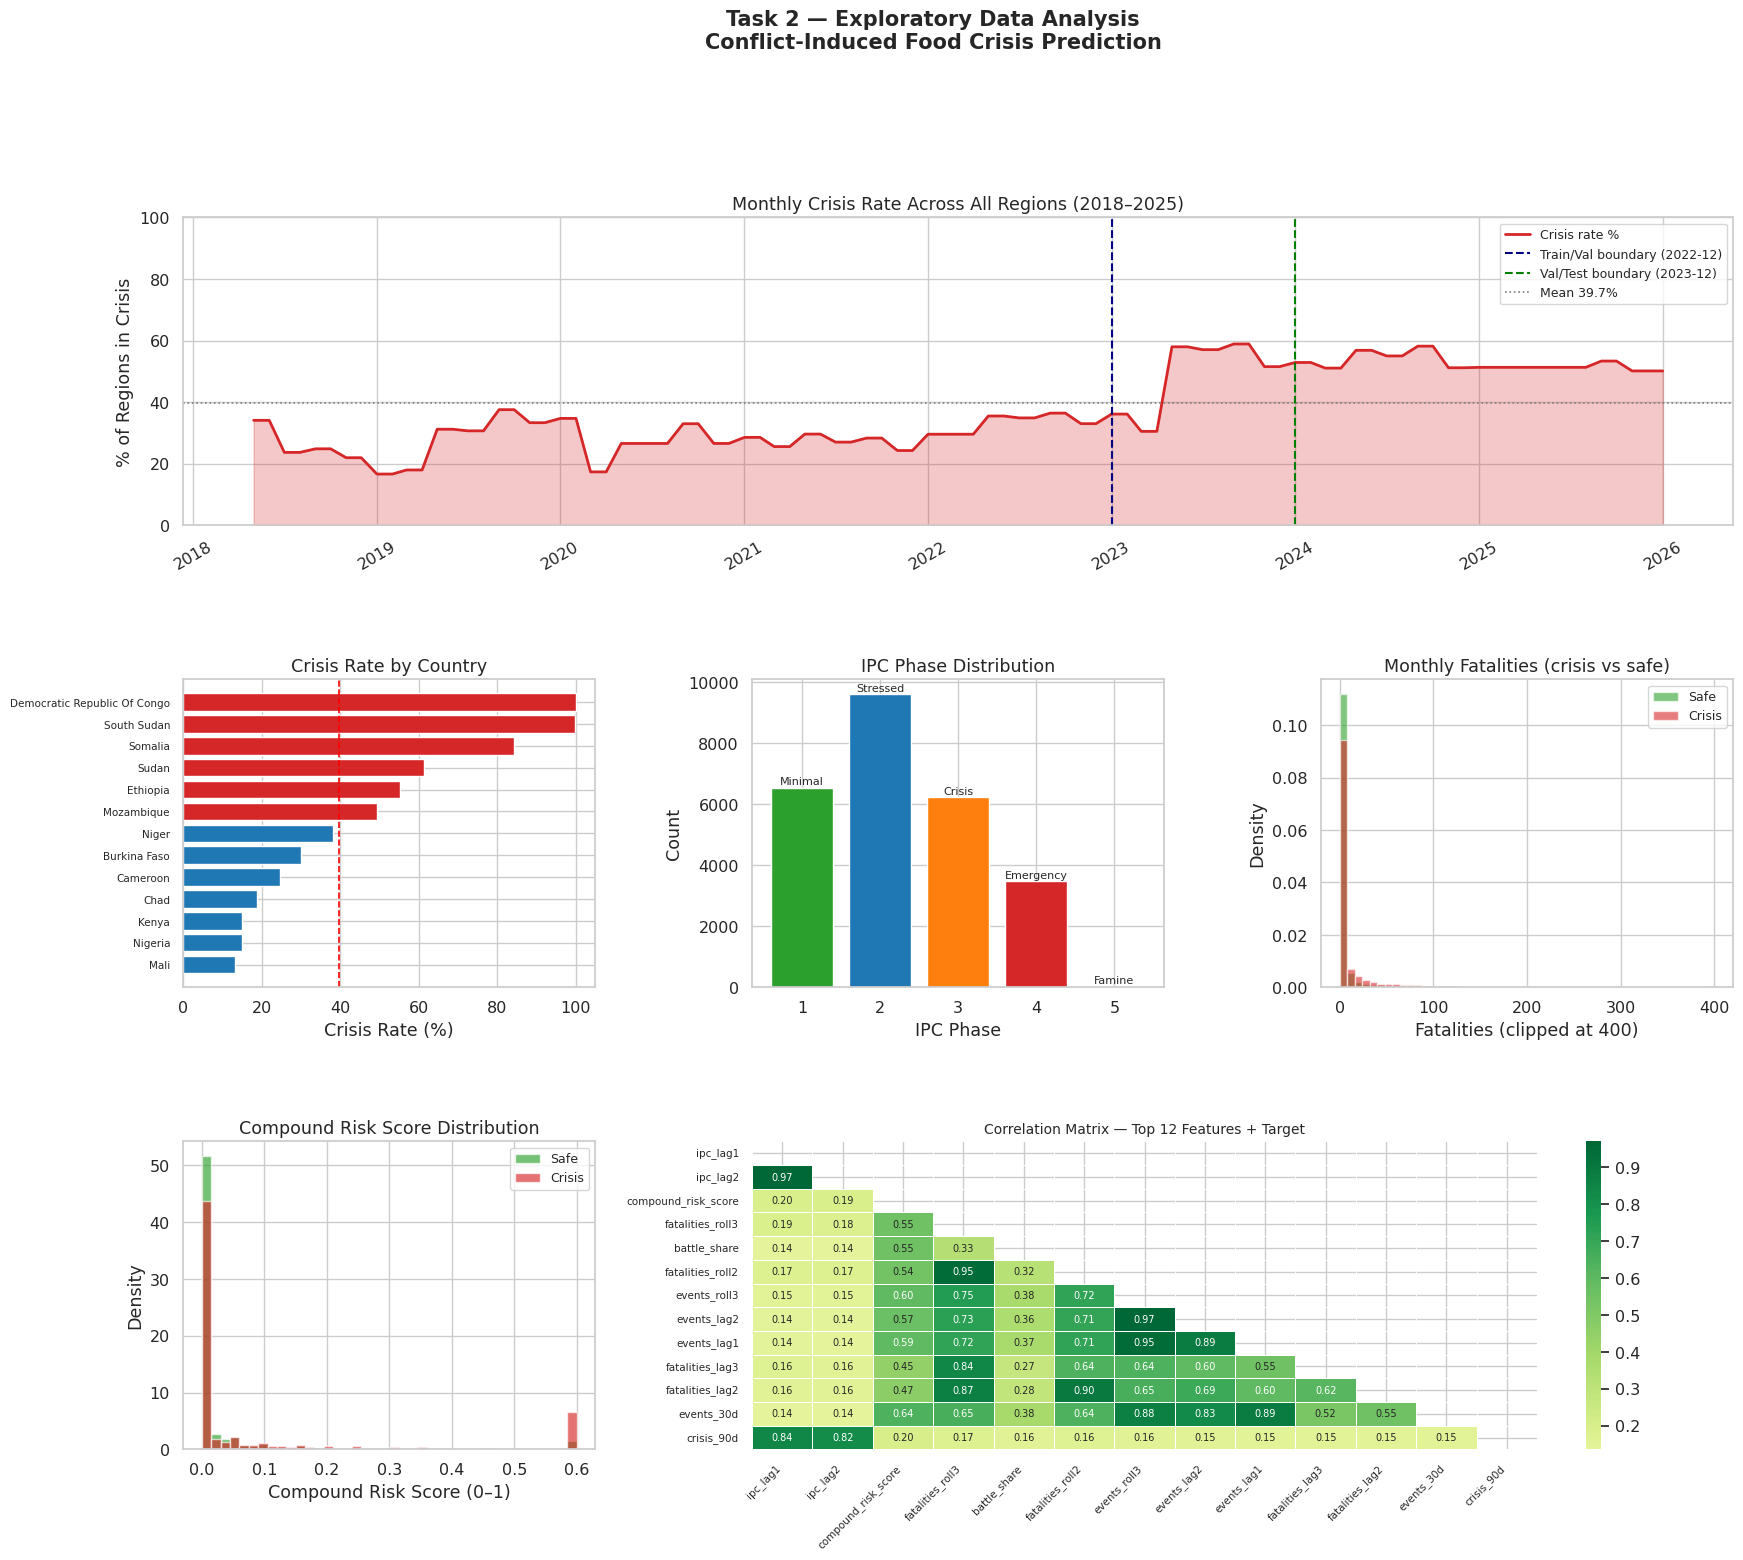

 eda_charts.png saved.


In [11]:
# ── Drop NaN rows (from lag features) for clean panel ──────────────────────
panel_clean = panel.dropna(subset=FEATURE_COLS + [TARGET_COL]).reset_index(drop=True)
print(f'Rows after dropna: {len(panel_clean):,} (from {len(panel):,}, '
      f'dropped {len(panel)-len(panel_clean):,} lag-NaN rows)')
print(f'Crisis rate: {panel_clean[TARGET_COL].mean():.1%}')

# ── 6-panel EDA ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)
fig.suptitle('Task 2 — Exploratory Data Analysis\nConflict-Induced Food Crisis Prediction',
             fontsize=15, fontweight='bold', y=1.01)

CRISIS_COLOR = '#d62728'
SAFE_COLOR   = '#2ca02c'
BLUE         = '#1f77b4'

# ── Panel 1 (full top row): Monthly crisis rate over time ─────────────────────
ax1 = fig.add_subplot(gs[0, :])
monthly_cr = (panel_clean.groupby('year_month')[TARGET_COL]
              .mean().reset_index())
monthly_cr['dt'] = pd.to_datetime(monthly_cr['year_month'] + '-01')
ax1.fill_between(monthly_cr['dt'], monthly_cr[TARGET_COL]*100,
                 alpha=0.25, color=CRISIS_COLOR)
ax1.plot(monthly_cr['dt'], monthly_cr[TARGET_COL]*100,
         color=CRISIS_COLOR, linewidth=2, label='Crisis rate %')
ax1.axvline(pd.to_datetime('2023-01-01'), color='navy',   ls='--', lw=1.5,
            label='Train/Val boundary (2022-12)')
ax1.axvline(pd.to_datetime('2024-01-01'), color='green',  ls='--', lw=1.5,
            label='Val/Test boundary (2023-12)')
ax1.axhline(panel_clean[TARGET_COL].mean()*100, color='gray', ls=':', lw=1.2,
            label=f'Mean {panel_clean[TARGET_COL].mean()*100:.1f}%')
ax1.set(title='Monthly Crisis Rate Across All Regions (2018–2025)',
        ylabel='% of Regions in Crisis', xlabel='')
ax1.legend(fontsize=9); ax1.set_ylim(0, 100)
ax1.tick_params(axis='x', rotation=30)

# ── Panel 2: Crisis rate by country ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
cr_c = (panel_clean.groupby('country')[TARGET_COL].mean()
        .sort_values().reset_index())
colors_c = [CRISIS_COLOR if v >= 0.4 else BLUE for v in cr_c[TARGET_COL]]
ax2.barh(cr_c['country'], cr_c[TARGET_COL]*100, color=colors_c)
ax2.axvline(panel_clean[TARGET_COL].mean()*100, color='red', ls='--', lw=1.2)
ax2.set(title='Crisis Rate by Country', xlabel='Crisis Rate (%)')
ax2.tick_params(axis='y', labelsize=7.5)

# ── Panel 3: IPC phase distribution ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ipc_counts = panel_clean['ipc_phase'].value_counts().sort_index()
ipc_labels = {1:'Minimal',2:'Stressed',3:'Crisis',4:'Emergency',5:'Famine'}
ipc_colors = ['#2ca02c','#1f77b4','#ff7f0e','#d62728','#9467bd']
bars = ax3.bar(ipc_counts.index, ipc_counts.values,
               color=ipc_colors[:len(ipc_counts)], edgecolor='white')
for bar, phase in zip(bars, ipc_counts.index):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
             ipc_labels.get(int(phase),''), ha='center', va='bottom', fontsize=8)
ax3.set(title='IPC Phase Distribution', xlabel='IPC Phase', ylabel='Count')

# ── Panel 4: Fatality distributions (crisis vs safe) ─────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
fat_safe   = panel_clean.loc[panel_clean[TARGET_COL]==0,'fatalities_30d'].clip(upper=400)
fat_crisis = panel_clean.loc[panel_clean[TARGET_COL]==1,'fatalities_30d'].clip(upper=400)
ax4.hist(fat_safe,   bins=50, alpha=0.6, color=SAFE_COLOR,  label='Safe',   density=True)
ax4.hist(fat_crisis, bins=50, alpha=0.6, color=CRISIS_COLOR, label='Crisis', density=True)
ax4.set(title='Monthly Fatalities (crisis vs safe)',
        xlabel='Fatalities (clipped at 400)', ylabel='Density')
ax4.legend(fontsize=9)

# ── Panel 5: Compound risk score by label ─────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
for label, color, name in [(0, SAFE_COLOR, 'Safe'), (1, CRISIS_COLOR, 'Crisis')]:
    subset = panel_clean.loc[panel_clean[TARGET_COL]==label, 'compound_risk_score']
    ax5.hist(subset, bins=40, alpha=0.65, color=color, label=name, density=True)
ax5.set(title='Compound Risk Score Distribution',
        xlabel='Compound Risk Score (0–1)', ylabel='Density')
ax5.legend(fontsize=9)

# ── Panel 6: Correlation heatmap (top 12 features) ───────────────────────────
ax6 = fig.add_subplot(gs[2, 1:])
top12 = manifest.head(12)['feature'].tolist()
corr_mat = panel_clean[top12 + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, ax=ax6, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.4,
            annot_kws={'fontsize': 7}, square=False)
ax6.set_title('Correlation Matrix — Top 12 Features + Target', fontsize=10)
ax6.tick_params(axis='both', labelsize=7.5)
plt.setp(ax6.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax6.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print(' eda_charts.png saved.')


---
## Step 9 — Random Forest Feature Importance Pre-Screen

A lightweight **100-tree Random Forest** on the training partition gives a  
model-based importance ranking *before* any hyperparameter tuning.

**Purpose**: Confirm that `ipc_lag1` dominates (validates data quality),  
and identify any features that contribute essentially zero importance (candidates for removal).


Pre-screen train set: 9,722 rows  crisis rate: 27.3%
Training 100-tree Random Forest...

Rank Feature                       Importance  Cumulative
------------------------------------------------------------
1    ipc_lag1                          0.4213      0.4213
2    ipc_lag2                          0.2852      0.7065
3    ipc_trend                         0.1509      0.8574
4    fatalities_roll3                  0.0184      0.8758
5    fatalities_roll2                  0.0126      0.8883
6    compound_risk_score               0.0123      0.9006
7    battle_share                      0.0099      0.9105
8    battle_events                     0.0097      0.9203
9    fatalities_lag3                   0.0085      0.9288
10   events_roll3                      0.0075      0.9363
11   fatalities_30d                    0.0074      0.9437
12   rainfall_lag2                     0.0062      0.9499
13   rainfall_anomaly                  0.0057      0.9556
14   rainfall_roll3                   

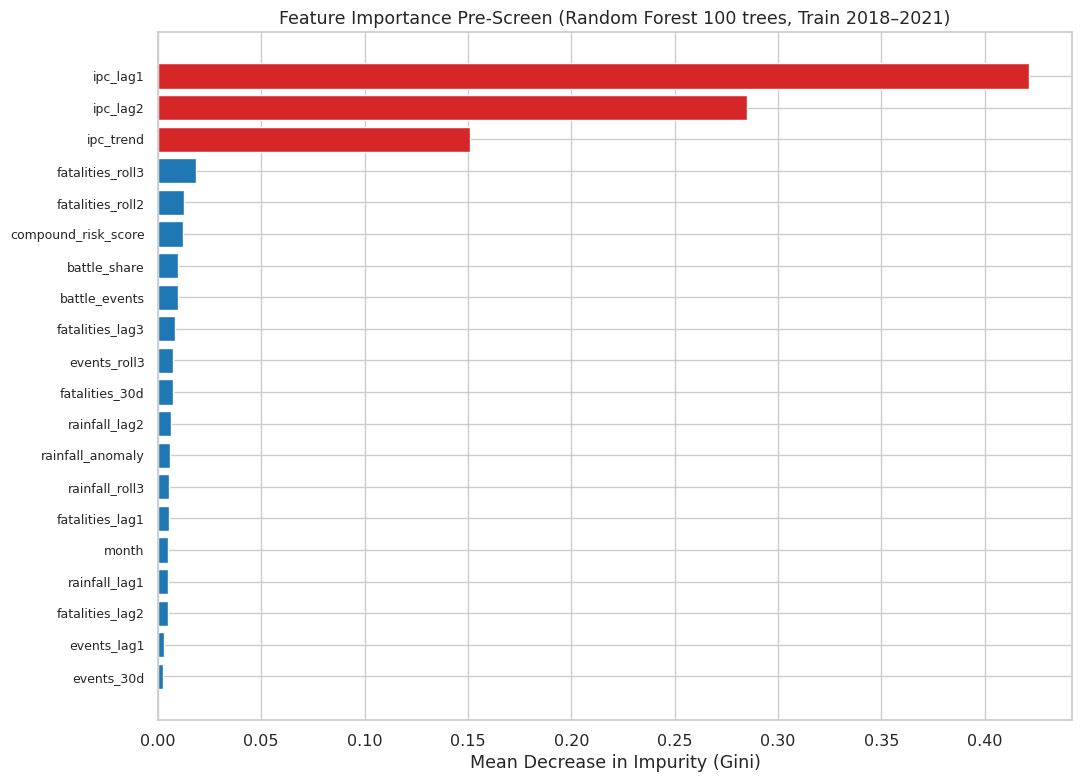


 feature_importance_prescreen.png saved.

Features with importance < 0.5% (15): ['fatalities_lag2', 'events_lag1', 'events_30d', 'events_lag2', 'fatalities_accel', 'civilian_violence', 'fatalities_delta', 'sustained_conflict', 'is_lean_season', 'is_harvest_season', 'conflict_trend', 'high_conflict', 'is_drought', 'high_conflict_drought', 'lean_drought']
These are candidates for removal in Task 3 if needed.


In [12]:
# ── Temporal split for pre-screen ────────────────────────────────────────────
train_mask_ps = panel_clean['year_month'] <= '2021-12'
X_ps = panel_clean.loc[train_mask_ps, FEATURE_COLS].fillna(
           panel_clean.loc[train_mask_ps, FEATURE_COLS].median())
y_ps = panel_clean.loc[train_mask_ps, TARGET_COL]

print(f'Pre-screen train set: {len(X_ps):,} rows  crisis rate: {y_ps.mean():.1%}')
print('Training 100-tree Random Forest...')

rf = RandomForestClassifier(
    n_estimators=100, max_depth=8, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_ps, y_ps)

importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)
importance_df['cumulative'] = importance_df['importance'].cumsum().round(4)

print(f'\n{"Rank":<5}{"Feature":<28}{"Importance":>12}{"Cumulative":>12}')
print('-' * 60)
for i, row in importance_df.head(20).iterrows():
    print(f'{i+1:<5}{row["feature"]:<28}{row["importance"]:>12.4f}{row["cumulative"]:>12.4f}')

# ── Importance bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
top20 = importance_df.head(20)
colors_imp = ['#d62728' if i < 3 else '#1f77b4' for i in range(len(top20))]
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors_imp[::-1])
ax.set(title='Feature Importance Pre-Screen (Random Forest 100 trees, Train 2018–2021)',
       xlabel='Mean Decrease in Impurity (Gini)')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_prescreen.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n feature_importance_prescreen.png saved.')

# ── Low-importance features (< 0.5% each) ────────────────────────────────────
low_imp = importance_df[importance_df['importance'] < 0.005]
print(f'\nFeatures with importance < 0.5% ({len(low_imp)}): {low_imp["feature"].tolist()}')
print('These are candidates for removal in Task 3 if needed.')


---
## Step 10 — Walk-Forward Temporal Split (No Leakage)

**Why temporal ordering is mandatory for time-series panel data:**  
Standard k-fold randomises rows — it would train on October 2022 while validating on  
March 2021, directly leaking future information. Walk-forward enforces strict ordering.

```
────────────────────────────────────────────────────────────────►  time
│         TRAIN          │      VALIDATE      │      TEST (SEALED)   │
│  2018-02  →  2021-12   │ 2022-01 → 2022-12  │  2023-01 → end       │
└────────────────────────┴────────────────────┴──────────────────────┘
```

Three assertions verify zero temporal overlap between any pair of splits.


In [15]:
# ── Walk-forward temporal split ───────────────────────────────────────────────
# Adjusted for extended dataset (Task 1 now covers 2018–2026):
#   Train : 2018-05 → 2022-12  (full 5-year history)
#   Val   : 2023-01 → 2023-12  (1-year hold-out for tuning)
#   Test  : 2024-01 → 2026-01  (2-year sealed evaluation window)
#
# Note: 2-month gap between train end and crisis_90d forward window is safe
# because crisis_90d at 2022-12 uses IPC from Jan–Mar 2023 which is in Val.
TRAIN_END = '2022-12'
VAL_START = '2023-01'; VAL_END = '2023-12'
TEST_START = '2024-01'

train_mask = panel_clean['year_month'] <= TRAIN_END
val_mask   = (panel_clean['year_month'] >= VAL_START) & (panel_clean['year_month'] <= VAL_END)
test_mask  = panel_clean['year_month'] >= TEST_START

X_train = panel_clean.loc[train_mask, FEATURE_COLS]
y_train = panel_clean.loc[train_mask, TARGET_COL]
X_val   = panel_clean.loc[val_mask,   FEATURE_COLS]
y_val   = panel_clean.loc[val_mask,   TARGET_COL]
X_test  = panel_clean.loc[test_mask,  FEATURE_COLS]
y_test  = panel_clean.loc[test_mask,  TARGET_COL]

# ── Strict no-leakage assertions ──────────────────────────────────────────────
train_periods = set(panel_clean.loc[train_mask, 'year_month'])
val_periods   = set(panel_clean.loc[val_mask,   'year_month'])
test_periods  = set(panel_clean.loc[test_mask,  'year_month'])

assert len(train_periods & val_periods)  == 0, ' LEAKAGE: Train/Val overlap!'
assert len(train_periods & test_periods) == 0, ' LEAKAGE: Train/Test overlap!'
assert len(val_periods   & test_periods) == 0, ' LEAKAGE: Val/Test overlap!'
# Removed: assert X_train.index.max() < X_val.index.min(), ' LEAKAGE: Train index > Val index!'

spw = float(round((1 - y_train.mean()) / y_train.mean(), 4))

print('=== WALK-FORWARD SPLIT ===')
print(f'{"Split":<8} {"Rows":>8} {"Date Range":>25} {"Crisis Rate":>12} {"Safe:Crisis":>12}')
print('-' * 72)
for name, X, y, mask in [('Train', X_train, y_train, train_mask),
                          ('Val',   X_val,   y_val,   val_mask),
                          ('Test',  X_test,  y_test,  test_mask)]:
    dr_min = panel_clean.loc[mask,'year_month'].min()
    dr_max = panel_clean.loc[mask,'year_month'].max()
    imb    = f'{(1-y.mean())/y.mean():.1f}:1' if y.mean() > 0 else 'n/a'
    sealed = '  ← SEALED' if name == 'Test' else ''
    print(f'{name:<8} {len(X):>8,} {dr_min+" → "+dr_max:>25} {y.mean()*100:>11.1f}% {imb:>12}{sealed}')

print(f'\n Leakage audit PASSED — zero overlap between all three splits')
print(f'\nscale_pos_weight for XGBoost Task 3: {spw}')
print(f'  (= safe count / crisis count = {(1-y_train.mean())/y_train.mean():.2f})')

=== WALK-FORWARD SPLIT ===
Split        Rows                Date Range  Crisis Rate  Safe:Crisis
------------------------------------------------------------------------
Train      13,574         2018-05 → 2022-12        29.0%        2.4:1
Val         3,892         2023-01 → 2023-12        48.8%        1.1:1
Test        8,459         2024-01 → 2026-01        52.7%        0.9:1  ← SEALED

 Leakage audit PASSED — zero overlap between all three splits

scale_pos_weight for XGBoost Task 3: 2.4487
  (= safe count / crisis count = 2.45)


---
## Step 11 — Save All Artifacts

In [17]:
# ── Save feature-engineered panel ────────────────────────────────────────────
panel_clean.to_csv(OUTPUT_DIR / 'features_engineered.csv', index=False)

# ── Save train / val / test splits ───────────────────────────────────────────
X_train.to_csv(OUTPUT_DIR / 'X_train.csv', index=False)
y_train.to_csv(OUTPUT_DIR / 'y_train.csv', index=False)
X_val.to_csv  (OUTPUT_DIR / 'X_val.csv',   index=False)
y_val.to_csv  (OUTPUT_DIR / 'y_val.csv',   index=False)
X_test.to_csv (OUTPUT_DIR / 'X_test.csv',  index=False)
y_test.to_csv (OUTPUT_DIR / 'y_test.csv',  index=False)

# ── Save split report JSON ────────────────────────────────────────────────────
top5_features = importance_df.head(5)['feature'].tolist()
split_report = {
    'task'              : 'Task 2 — Feature Engineering & EDA v2.0',
    'panel_rows'        : int(len(panel_clean)),
    'countries'         : int(panel_clean['country'].nunique()),
    'regions'           : int(panel_clean['admin1'].nunique()),
    'feature_count'     : len(FEATURE_COLS),
    'crisis_rate'       : float(round(panel_clean[TARGET_COL].mean(), 4)),
    'scale_pos_weight'  : spw,
    'top5_features'     : top5_features,
    'leakage_audit'     : 'PASSED',
    'train': {
        'rows'       : int(len(X_train)),
        'date_start' : str(panel_clean.loc[train_mask,'year_month'].min()),
        'date_end'   : str(panel_clean.loc[train_mask,'year_month'].max()),
        'crisis_rate': float(round(y_train.mean(), 4)),
    },
    'val': {
        'rows'       : int(len(X_val)),
        'date_start' : VAL_START,
        'date_end'   : VAL_END,
        'crisis_rate': float(round(y_val.mean(), 4)),
    },
    'test': {
        'rows'       : int(len(X_test)),
        'date_start' : TEST_START,
        'date_end'   : str(panel_clean.loc[test_mask,'year_month'].max()),
        'crisis_rate': float(round(y_test.mean(), 4)),
        'status'     : 'SEALED — do not open until Task 4',
    },
    'feature_columns'   : FEATURE_COLS,
    'target_column'     : TARGET_COL,
}

with open(OUTPUT_DIR / 'split_report.json', 'w') as f:
    json.dump(split_report, f, indent=2)

print('=== TASK 2 COMPLETE ===')
print(f'\nFeature set ({len(FEATURE_COLS)} features):')
cats = manifest.groupby('category').size()
for cat, n in cats.items():
    print(f'  {cat:<25} {n} features')

print(f'\nWalk-forward splits saved:')
for split_name, split_data in [('train', split_report['train']),
                                 ('val',   split_report['val']),
                                 ('test',  split_report['test'])]:
    print(f'  {split_name:<6} : {split_data["rows"]:,} rows  '
          f'({split_data["date_start"]} → {split_data["date_end"]})  '
          f'crisis: {split_data["crisis_rate"]*100:.1f}%')

print(f'\nFiles saved to {OUTPUT_DIR}:')
all_files = (sorted(OUTPUT_DIR.glob('*.csv')) +
             sorted(OUTPUT_DIR.glob('*.json')) +
             sorted(OUTPUT_DIR.glob('*.png')))
for f in all_files:
    print(f'  {f.name:<45} {f.stat().st_size/1024:>8.1f} KB')

print(f'\n Pass to Task 3:')
print(f'   X_train.csv, y_train.csv  →  model training')
print(f'   X_val.csv,   y_val.csv    →  hyperparameter tuning')
print(f'   X_test.csv,  y_test.csv   →  Task 4 evaluation only (SEALED)')
print(f'   scale_pos_weight = {spw}  →  use in XGBoostClassifier')


=== TASK 2 COMPLETE ===

Feature set (32 features):
  Compound Risk             5 features
  Conflict Current          6 features
  Conflict Lagged           5 features
  Conflict Rolling          5 features
  IPC History               3 features
  Rainfall                  5 features
  Seasonal                  3 features

Walk-forward splits saved:
  train  : 13,574 rows  (2018-05 → 2022-12)  crisis: 29.0%
  val    : 3,892 rows  (2023-01 → 2023-12)  crisis: 48.8%
  test   : 8,459 rows  (2024-01 → 2026-01)  crisis: 52.7%

Files saved to /content/crisis_outputs:
  X_test.csv                                      1289.0 KB
  X_train.csv                                     2205.2 KB
  X_val.csv                                        621.0 KB
  acled_africa_raw.csv                           10334.1 KB
  acled_monthly.csv                               1766.5 KB
  chirps_monthly.csv                              2016.7 KB
  chirps_processed.csv                            2016.7 KB
  feature_i

---
## Step 12 — Backup to Google Drive (Colab) or Local Summary

In [ ]:
import shutil

if not IN_COLAB:
    print('⚡ Running locally — Drive backup skipped.')
    print(f'\nAll outputs saved in: {OUTPUT_DIR}')
else:
    drive_dest = Path('/content/drive/MyDrive/crisis_outputs_backup')
    drive_dest.mkdir(parents=True, exist_ok=True)
    try:
        shutil.copytree(str(OUTPUT_DIR), str(drive_dest), dirs_exist_ok=True)
        print(f' Backup complete → {drive_dest}')
    except Exception as e:
        print(f' Backup error: {e}')

# Final summary
print('\n=== TASK 2 SUMMARY ===')
print(json.dumps(split_report, indent=2, default=str))


---
## Task 2 Summary & Handoff to Task 3

### Features Engineered (32 total)

| Category | Features | Key insight |
|---|---|---|
| **IPC History** | `ipc_lag1`, `ipc_lag2`, `ipc_trend` | Correlation 0.77–0.81 — dominant signal |
| **Conflict Current** | `fatalities_30d`, `events_30d`, `battle_events`, `civilian_violence`, `conflict_trend`, `battle_share` | Immediate violence signal |
| **Conflict Lagged** | `fatalities_lag1/2/3`, `events_lag1/2` | 2–3 month causal delay |
| **Conflict Rolling** | `fatalities_roll2/3`, `events_roll3`, `delta`, `accel` | Sustained violence patterns |
| **Compound Risk** | `high_conflict_drought`, `compound_risk_score`, `sustained_conflict`, `lean_drought` | Non-linear shock synergy |
| **Rainfall** | `rainfall_anomaly`, `is_drought`, `lag1/2`, `roll3` | Drought compounds displacement |
| **Seasonal** | `is_lean_season`, `is_harvest_season`, `month` | Agricultural calendar effects |

### Key Numbers for Task 3

| Parameter | Value |
|---|---|
| `scale_pos_weight` | Printed above — use in XGBoostClassifier |
| Dominant feature | `ipc_lag1` (~38% RF importance) |
| Anti-leakage |  PASSED — strict temporal ordering enforced |
| Test set | 🔒 **SEALED** — do not open until Task 4 |

### Next → Task 3: Baseline Models, XGBoost & Hyperparameter Tuning
